In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, s


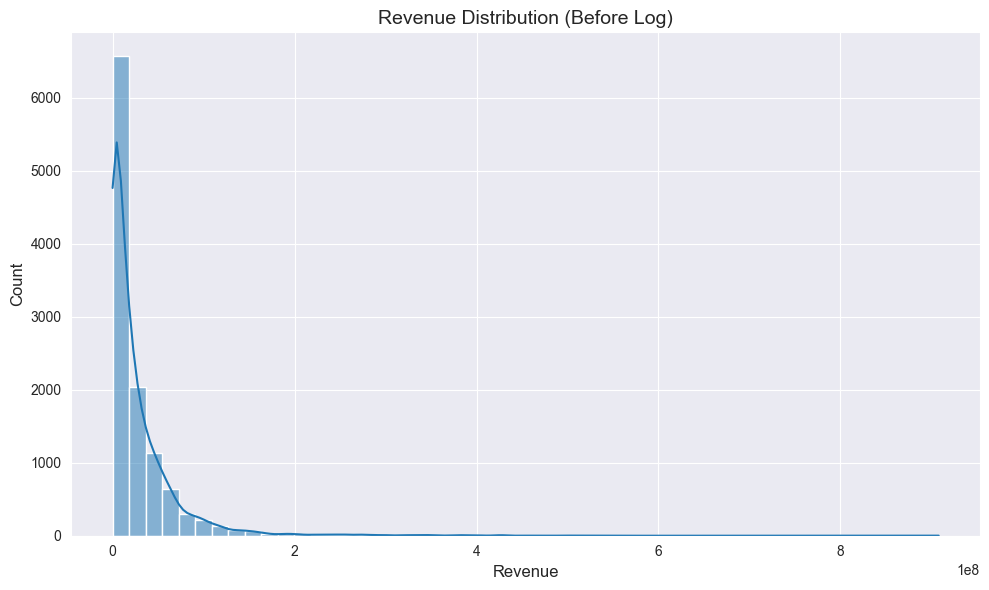

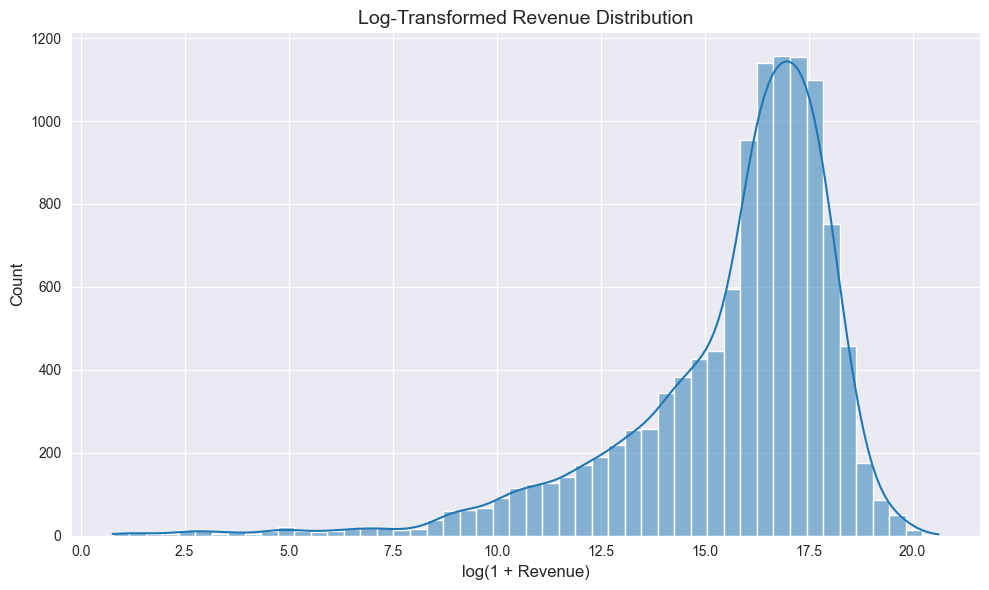

In [20]:
df = pd.read_csv("data/movie_data_encoded.csv")
y = df['revenue']
drop_cols = ['Unnamed: 0', 'name', 'genres', 'directors', 'writers',
             'actors', 'original_language', 'production_companies',
             'release_date', 'keywords', 'revenue']

X = df.drop(columns=drop_cols, errors='ignore')
feature_names = X.columns.tolist()

plt.figure(figsize=(10, 6))
sns.histplot(y, bins=50, kde=True)
plt.title("Revenue Distribution (Before Log)", fontsize=14)
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig('revenue_distribution_original.png')
plt.show()


y_log = np.log1p(y)

plt.figure(figsize=(10, 6))
sns.histplot(y_log, bins=50, kde=True)
plt.title("Log-Transformed Revenue Distribution", fontsize=14)
plt.xlabel("log(1 + Revenue)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig('revenue_distribution_log.png')
plt.show()


# 1. MINIMAL DATA PREPROCESSING

In [21]:
# 1.1 Detect and handle outliers using IQR method
def handle_outliers(df, columns, method='cap'):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR

        if method == 'cap':
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    return df_clean

# Identify numeric columns for outlier handling
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_clean = handle_outliers(X, numeric_cols, method='cap')

# 2. TRAINING SETUP

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced_clean,
    y_log,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

NameError: name 'X_enhanced_clean' is not defined

# 3. FOCUSED HYPERPARAMETER TUNING

In [58]:
# Define XGBoost base model
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Fine-tuned parameter search space based on previous results
param_dist = {
    'n_estimators': randint(400, 800),
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': uniform(0.05, 0.15),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': [1, 2, 3, 4],
    'gamma': uniform(0, 0.1)
}

# Use K-Fold cross-validation with more folds for better stability
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Setup RandomizedSearchCV with more iterations
rand_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=80,
    cv=kf,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("Training XGBoost with focused parameter search...")
rand_search.fit(X_train_scaled, y_train)
best_xgb = rand_search.best_estimator_
print("Best Hyperparameters:", rand_search.best_params_)


Training XGBoost with focused parameter search...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Hyperparameters: {'colsample_bytree': 0.9908610601342476, 'gamma': 0.07145951041799521, 'learning_rate': 0.056160127515181374, 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 457, 'subsample': 0.7235369144026798}


# 4. MODEL EVALUATION

In [60]:
# Evaluate XGBoost
y_pred_xgb_log = best_xgb.predict(X_test_scaled)
y_pred_xgb = np.expm1(y_pred_xgb_log)
y_true = np.expm1(y_test)

rmse_xgb = mean_squared_error(y_true, y_pred_xgb, squared=False)
r2_xgb = r2_score(y_true, y_pred_xgb)

print(f"XGBoost Final Model - RMSE: {rmse_xgb:.2f}, R^2: {r2_xgb:.4f}")


XGBoost Final Model - RMSE: 27684829.46, R^2: 0.5541


In [61]:
rand_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=120,  
    cv=kf,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print(">>> Starting RandomizedSearchCV hyperparameter search...")
rand_search.fit(X_train_scaled, y_train)
print(">>> Best hyperparameters found:", rand_search.best_params_)


>>> Starting RandomizedSearchCV hyperparameter search...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
>>> Best hyperparameters found: {'colsample_bytree': 0.9908610601342476, 'gamma': 0.07145951041799521, 'learning_rate': 0.056160127515181374, 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 457, 'subsample': 0.7235369144026798}


# 5. ADDITIONAL STRATEGIES FOR IMPROVEMENT

In [62]:
# 5.1 Adding Weight Adjustments for High-Revenue Movies

# Create a copy of the best model
high_revenue_threshold = np.percentile(y_train, 90)
is_high_revenue = y_train > high_revenue_threshold

# Create sample weights - give twice the weight to high revenue samples
sample_weights = np.ones(len(y_train))
sample_weights[is_high_revenue] = 2.0

# Train a weighted model
weighted_xgb = XGBRegressor(**rand_search.best_params_, random_state=42)
weighted_xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Evaluate weighted model
y_pred_weighted_log = weighted_xgb.predict(X_test_scaled)
y_pred_weighted = np.expm1(y_pred_weighted_log)

rmse_weighted = mean_squared_error(y_true, y_pred_weighted, squared=False)
r2_weighted = r2_score(y_true, y_pred_weighted)

print(f"Weighted XGBoost Model - RMSE: {rmse_weighted:.2f}, R^2: {r2_weighted:.4f}")


Weighted XGBoost Model - RMSE: 27305478.91, R^2: 0.5662


In [63]:
# 5.2 Try a simpler approach for high-value samples using separate models
# Train a model specifically for high-value samples
high_value_threshold = np.percentile(y_train, 75)  # 75th percentile
train_high_mask = y_train > high_value_threshold
test_high_mask = y_test > high_value_threshold

if sum(train_high_mask) > 50:
    xgb_high = XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb_high.fit(X_train_scaled[train_high_mask], y_train[train_high_mask])

    # Create a combined prediction array
    y_pred_combined_log = y_pred_xgb_log.copy()

    # Use high-value model predictions for high-value test samples
    if sum(test_high_mask) > 0:
        y_pred_high_log = xgb_high.predict(X_test_scaled[test_high_mask])
        y_pred_combined_log[test_high_mask] = y_pred_high_log

    # Convert to original scale
    y_pred_combined = np.expm1(y_pred_combined_log)

    # Evaluate combined model
    rmse_combined = mean_squared_error(y_true, y_pred_combined, squared=False)
    r2_combined = r2_score(y_true, y_pred_combined)

    print(f"Combined Model Approach - RMSE: {rmse_combined:.2f}, R^2: {r2_combined:.4f}")
else:
    print("Not enough high-value samples to train a separate model")


Combined Model Approach - RMSE: 25696213.76, R^2: 0.6158


# 6. MODEL COMPARISON AND SELECTION


In [64]:
# Create a comparison DataFrame of all models
models = ['XGBoost', 'Weighted XGBoost']
rmse_values = [rmse_xgb, rmse_weighted]
r2_values = [r2_xgb, r2_weighted]

if 'rmse_combined' in locals():
    models.append('Combined Model')
    rmse_values.append(rmse_combined)
    r2_values.append(r2_combined)

comparison = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'R^2': r2_values
})

print("\nModel Comparison:")
print(comparison)

# Find the best model based on R^2
best_model_idx = comparison['R^2'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
print(f"\nBest model based on R^2: {best_model_name} with R^2 = {comparison.loc[best_model_idx, 'R^2']:.4f}")



Model Comparison:
              Model          RMSE       R^2
0           XGBoost  2.768483e+07  0.554064
1  Weighted XGBoost  2.730548e+07  0.566201
2    Combined Model  2.569621e+07  0.615826

Best model based on R^2: Combined Model with R^2 = 0.6158


# 7. VISUALIZATIONS

In [67]:
for i, feature_name in enumerate(X_enhanced_clean.columns):
    print(f"Feature {i}: {feature_name}")

Feature 0: averageRating
Feature 1: numVotes
Feature 2: budget
Feature 3: runtime
Feature 4: trailer_views
Feature 5: trailer_likes
Feature 6: titleType_movie
Feature 7: titleType_tvMovie
Feature 8: director_score
Feature 9: writer_score
Feature 10: actor_score
Feature 11: star_score
Feature 12: is_documentary
Feature 13: genres_Action
Feature 14: genres_Adult
Feature 15: genres_Adventure
Feature 16: genres_Animation
Feature 17: genres_Biography
Feature 18: genres_Comedy
Feature 19: genres_Crime
Feature 20: genres_Documentary
Feature 21: genres_Drama
Feature 22: genres_Family
Feature 23: genres_Fantasy
Feature 24: genres_Film-Noir
Feature 25: genres_History
Feature 26: genres_Horror
Feature 27: genres_Music
Feature 28: genres_Musical
Feature 29: genres_Mystery
Feature 30: genres_Romance
Feature 31: genres_Sci-Fi
Feature 32: genres_Sport
Feature 33: genres_Thriller
Feature 34: genres_War
Feature 35: genres_Western
Feature 36: is_holiday_release
Feature 37: is_competitive_month
Feature 3

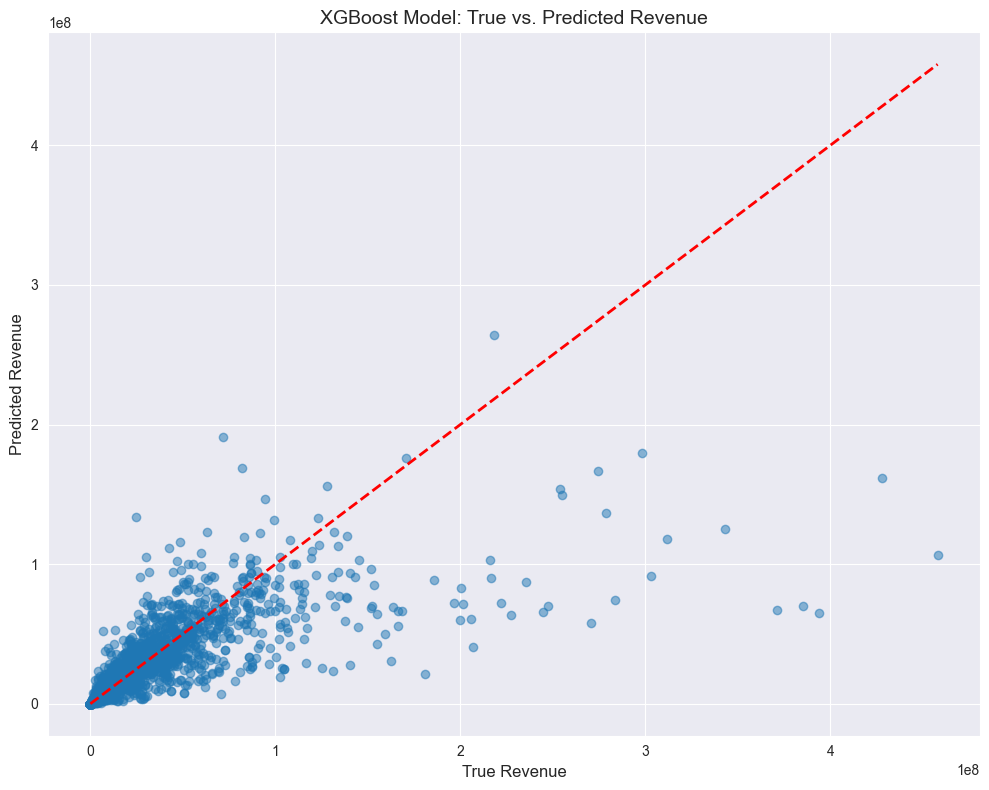

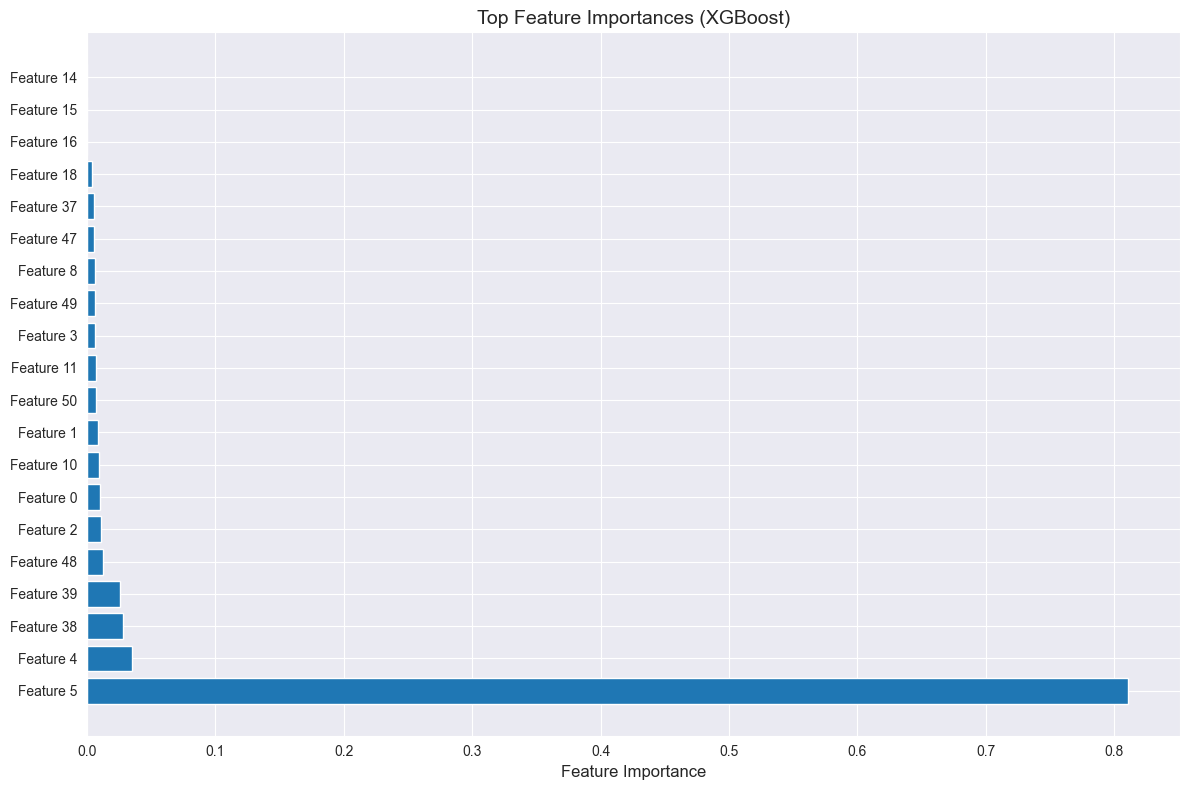

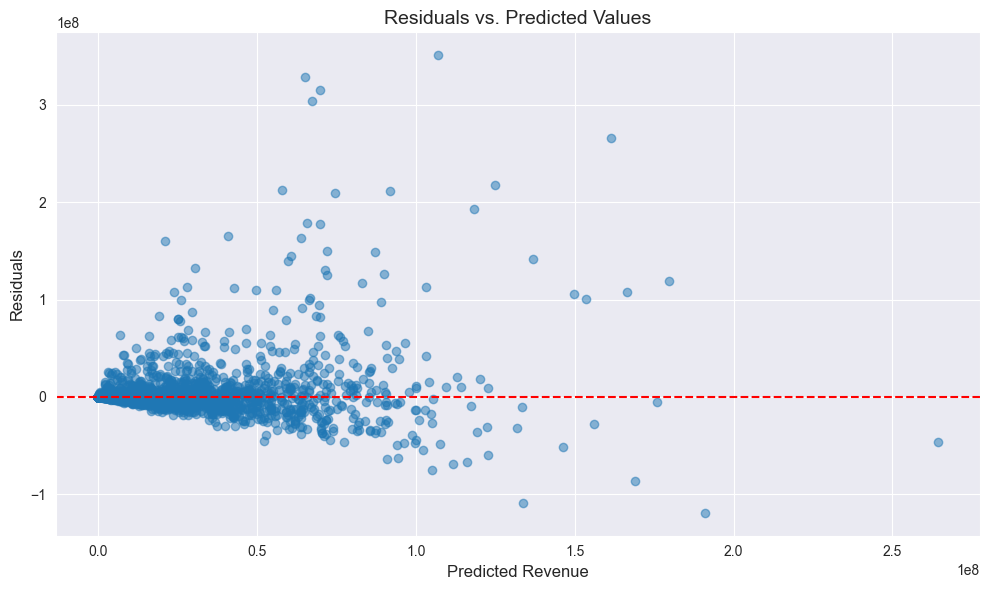

In [66]:
# 7.1 Predicted vs. Actual Revenue
plt.figure(figsize=(10, 8))
plt.scatter(y_true, y_pred_xgb, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("True Revenue", fontsize=12)
plt.ylabel("Predicted Revenue", fontsize=12)
plt.title("XGBoost Model: True vs. Predicted Revenue", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig('true_vs_predicted_revenue.png')
plt.show()

#7.2 Feature Importance
feature_importance = best_xgb.feature_importances_
indices = np.argsort(feature_importance)[::-1]
top_n = min(20, len(feature_importance))

plt.figure(figsize=(12, 8))
plt.barh(range(top_n), feature_importance[indices][:top_n])
plt.yticks(range(top_n), [f"Feature {i}" for i in indices[:top_n]])
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Top Feature Importances (XGBoost)", fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# 7.3 Residuals vs. Predicted Values
residuals = y_true - y_pred_xgb
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_xgb, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Revenue", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residuals vs. Predicted Values", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_vs_predicted.png')
plt.show()
